In [ ]:
# System dependencies
!apt-get install -y xvfb ffmpeg -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.


In [ ]:
# Python packages
!pip install highway-env stable-baselines3 gymnasium renderlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 66.6 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import highway_env
import numpy as np
import imageio
import matplotlib.pyplot as plt
from IPython.display import Image, display
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!apt-get install -y xvfb > /dev/null 2>&1
!pip install pyvirtualdisplay -q

from pyvirtualdisplay import Display
vdisplay = Display(visible=False, size=(600, 150))
vdisplay.start()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("highway-v0", render_mode="rgb_array")
obs, info = env.reset()

print("Obs shape:", obs.shape)
print("Action space:", env.action_space)
env.close()

Obs shape: (5, 5)
Action space: Discrete(5)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# import gymnasium as gym
# import highway_env
# import imageio
# import numpy as np
# from IPython.display import Image, display
# import os

# env = gym.make("highway-v0", render_mode="rgb_array")
# obs, _ = env.reset()

# frames = []
# print("reached here")
# frames.append(env.render())
# print("reached here 2")

# for _ in range(80):
#     action = env.action_space.sample()
#     obs, reward, done, truncated, info = env.step(action)
#     frames.append(env.render())
#     if done or truncated:
#         obs, _ = env.reset()
#         frames.append(env.render())

# env.close()

# # Sanity check for frames
# print(np.array(frames[0]).max())  # should now be > 0

# from google.colab import drive
# drive.mount('/content/drive')

# SAVE_DIR = "/content/drive/MyDrive/AVERT/"
# import os
# os.makedirs(SAVE_DIR, exist_ok=True)

# imageio.mimsave(os.path.join(SAVE_DIR, "random_agent.gif"), frames, fps=15)
# display(Image(os.path.join(SAVE_DIR, "random_agent.gif")))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/AVERT/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
# Curriculum Stage 1: Dense passive traffic, no adversaries
stage1_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "lanes_count": 4,
    "vehicles_count": 30,
    "duration": 40,
    "other_vehicles_type": "highway_env.vehicle.behavior.IDMVehicle",
    "collision_reward": -2,
    "high_speed_reward": 0.4,
    "right_lane_reward": 0.1,
    "lane_change_reward": 0.0,
    "reward_speed_range": [20, 30],
    "normalize_reward": True,
}

def make_stage1_env():
    env = gym.make("highway-v0")
    env.unwrapped.configure(stage1_config)
    return env

print("Stage 1 config ready")

Stage 1 config ready


In [ ]:
# Curriculum Stage 2: Aggressive drivers — tailgate, cut off, higher density
stage2_config = {
    **stage1_config,
    "vehicles_count": 40,
    "other_vehicles_type": "highway_env.vehicle.behavior.AggressiveVehicle",
    "collision_reward": -3,
}

def make_stage2_env():
    env = gym.make("highway-v0")
    env.unwrapped.configure(stage2_config)
    return env

print("Stage 2 config ready")

Stage 2 config ready


In [ ]:
from highway_env.vehicle.behavior import IDMVehicle

class PursuerVehicle(IDMVehicle):
    """
    A vehicle that actively pursues the ego agent —
    matches its lane and accelerates to close distance.
    """
    PURSUIT_GAIN = 1.5  # how aggressively it chases

    def act(self, action=None):
        ego = self.road.vehicles[0]  # ego is always index 0

        # Match ego lane
        if self.lane_index[2] < ego.lane_index[2]:
            action = "LANE_RIGHT"
        elif self.lane_index[2] > ego.lane_index[2]:
            action = "LANE_LEFT"
        else:
            # Same lane — floor it
            action = "FASTER"

        super().act(action)

print("PursuerVehicle defined")

PursuerVehicle defined


In [ ]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []

    def _on_step(self):
        if "episode" in self.locals.get("infos", [{}])[0]:
            r = self.locals["infos"][0]["episode"]["r"]
            self.rewards.append(r)
        return True

In [ ]:
import highway_env.vehicle.behavior as behavior
behavior.PursuerVehicle = PursuerVehicle  # register it

stage3_config = {
    **stage1_config,
    "vehicles_count": 30,
    "other_vehicles_type": "highway_env.vehicle.behavior.PursuerVehicle",
    "collision_reward": -5,
}

def make_stage3_env():
    env = gym.make("highway-v0")
    env.unwrapped.configure(stage3_config)
    return env

print("Stage 3 config ready")

Stage 3 config ready


In [ ]:
import gymnasium as gym
import highway_env
import imageio
import numpy as np
from IPython.display import Image, display
import os

def render_agent(model, config, filename="agent.gif", episodes=3):
    env = gym.make("highway-v0", render_mode="rgb_array")
    env.unwrapped.configure(config)
    frames = []
    rewards = []

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            frames.append(env.render())
            ep_reward += reward
            done = done or truncated
        rewards.append(ep_reward)
        print(f"Episode {ep+1} reward: {ep_reward:.2f}")

    env.close()

    save_path = os.path.join(SAVE_DIR, filename)
    imageio.mimsave(save_path, frames, fps=15)
    display(Image(save_path))
    print(f"Avg reward: {np.mean(rewards):.2f}")
    survival_rate = sum(1 for r in rewards if r > 0) / len(rewards)
    print(f"Survival rate: {survival_rate*100:.1f}%")

In [ ]:
def train_stage(make_env_fn, stage_name, timesteps=5000, model=None):
    """
    Train PPO on a given stage config.
    If model is passed, fine-tunes from existing weights (curriculum transfer).
    """
    vec_env = make_vec_env(make_env_fn, n_envs=1)
    logger = RewardLogger()

    checkpoint_cb = CheckpointCallback(
        save_freq=1000,
        save_path=os.path.join(SAVE_DIR, f"{stage_name}_checkpoints/"), # Modified to save to Drive
        name_prefix=f"avert_{stage_name}"
    )

    if model is None:
        model = PPO(
            "MlpPolicy",
            vec_env,
            verbose=1,
            n_steps=256,
            batch_size=64,
            n_epochs=10,
            learning_rate=3e-4,
            gamma=0.99,
        )

    else:
        model.set_env(vec_env)

    model.learn(total_timesteps=timesteps, callback=[checkpoint_cb, logger], reset_num_timesteps=False)
    model.save(os.path.join(SAVE_DIR, f"avert_{stage_name}_final")) # Modified to save to Drive

    # Save the reward data
    rewards_save_path = os.path.join(SAVE_DIR, f"avert_{stage_name}_rewards.npy")
    np.save(rewards_save_path, np.array(logger.rewards))
    print(f"Reward data for {stage_name} saved to {rewards_save_path}")

    print(f"{stage_name} training complete — model and rewards saved")
    return model, logger

To see the number of steps for each checkpoint, you can list the contents of the checkpoint directory and parse the filenames. The `CheckpointCallback` names the checkpoint files with the format `avert_{stage_name}_{step_number}_steps.zip`.

In [ ]:
import re

def get_checkpoint_steps(stage_name):
    checkpoint_dir = os.path.join(SAVE_DIR, f"{stage_name}_checkpoints/")
    if not os.path.exists(checkpoint_dir):
        print(f"Checkpoint directory {checkpoint_dir} does not exist.")
        return []

    checkpoint_info = []
    for filename in os.listdir(checkpoint_dir):
        match = re.match(f"avert_{stage_name}_(\\d+)_steps.zip", filename)
        if match:
            step_number = int(match.group(1))
            checkpoint_info.append((step_number, filename))
    # Sort by step number
    return sorted(checkpoint_info, key=lambda x: x[0])

# Example for Stage 3 checkpoints
stage3_checkpoint_info = get_checkpoint_steps("stage3")
print(f"Stage 3 Checkpoint steps and filenames: {stage3_checkpoint_info}")

# You can similarly check for other stages, e.g., 'stage1', 'stage2', 'roundabout_transfer', 'merge_transfer'
# stage1_checkpoint_info = get_checkpoint_steps("stage1")
# print(f"Stage 1 Checkpoint steps and filenames: {stage1_checkpoint_info}")

Stage 3 Checkpoint steps and filenames: [(11240, 'avert_stage3_11240_steps.zip'), (12240, 'avert_stage3_12240_steps.zip'), (13240, 'avert_stage3_13240_steps.zip'), (14240, 'avert_stage3_14240_steps.zip'), (15240, 'avert_stage3_15240_steps.zip')]


In [ ]:
output_filename = os.path.join(SAVE_DIR, "stage3_checkpoint_steps.txt")
with open(output_filename, "w") as f:
    for step, filename in stage3_checkpoint_info:
        f.write(f"Step: {step}, Filename: {filename}\n")

print(f"Stage 3 Checkpoint steps and filenames saved to {output_filename}")

Stage 3 Checkpoint steps and filenames saved to /content/drive/MyDrive/AVERT/stage3_checkpoint_steps.txt


In [ ]:
# Stage 1 — train from scratch
print("=== STAGE 1: Passive Traffic ===")
model, logger1 = train_stage(make_stage1_env, "stage1", timesteps=5000)

# Stage 2 — fine-tune from stage 1
print("\n=== STAGE 2: Aggressive Traffic ===")
model, logger2 = train_stage(make_stage2_env, "stage2", timesteps=5000, model=model)

# Stage 3 — fine-tune from stage 2
print("\n=== STAGE 3: Active Pursuers ===")
model, logger3 = train_stage(make_stage3_env, "stage3", timesteps=5000, model=model)

=== STAGE 1: Passive Traffic ===
Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 16.9     |
|    ep_rew_mean     | 14.3     |
| time/              |          |
|    fps             | 4        |
|    iterations      | 1        |
|    time_elapsed    | 54       |
|    total_timesteps | 256      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 16.4        |
|    ep_rew_mean          | 13.7        |
| time/                   |             |
|    fps                  | 4           |
|    iterations           | 2           |
|    time_elapsed         | 105         |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.009101048 |
|    clip_fraction        | 0.00781     |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | 0.00114     |
|    learning_rate        | 0.0003      |
|    loss                 | 20.7        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00993    |
|    value_loss           | 44.3        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 39.8         |
|    ep_rew_mean          | 36.6         |
| time/                   |              |
|    fps                  | 4            |
|    iterations           | 19           |
|    time_elapsed         | 981          |
|    total_timesteps      | 15104        |
| train/                  |              |
|    approx_kl            | 0.0044383816 |
|    clip_fraction        | 0.0785       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.439       |
|    explained_variance   | 3.49e-05     |
|    learning_rate        | 0.0003       |
|    loss                 | 22.2         |
|    n_updates            | 580          |
|    policy_gradient_loss | -0.00628     |
|    value_loss           | 90.9         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 39.8         |
|    ep_rew_mean          | 36.6         |
| time/                   |              |
|    fps                  | 4            |
|    iterations           | 20           |
|    time_elapsed         | 1036         |
|    total_timesteps      | 15360        |
| train/                  |              |
|    approx_kl            | 0.0005920059 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.418       |
|    explained_variance   | -0.000503    |
|    learning_rate        | 0.0003       |
|    loss                 | 6.43         |
|    n_updates            | 590          |
|    policy_gradient_loss | -0.000177    |
|    value_loss           | 17           |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reward data for stage3 saved to /content/drive/MyDrive/AVERT/avert_stage3_rewards.npy
stage3 training complete — model and rewards saved


In [ ]:
print("=== BASELINE: Training from scratch on Stage 3 ===")
model_scratch, logger_scratch = train_stage(make_stage3_env, "stage3_scratch", timesteps=15000, model=None)


=== BASELINE: Training from scratch on Stage 3 ===
Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.8     |
|    ep_rew_mean     | 10.4     |
| time/              |          |
|    fps             | 4        |
|    iterations      | 1        |
|    time_elapsed    | 56       |
|    total_timesteps | 256      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12.4        |
|    ep_rew_mean          | 11          |
| time/                   |             |
|    fps                  | 4           |
|    iterations           | 2           |
|    time_elapsed         | 109         |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.008869349 |
|    clip_fraction        | 0.0156      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | 0.00858     |
|    learning_rate        | 0.0003      |
|    loss                 | 13.3        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00982    |
|    value_loss           | 33.2        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 39.8         |
|    ep_rew_mean          | 36.5         |
| time/                   |              |
|    fps                  | 4            |
|    iterations           | 39           |
|    time_elapsed         | 2106         |
|    total_timesteps      | 9984         |
| train/                  |              |
|    approx_kl            | 0.0013008465 |
|    clip_fraction        | 0.0141       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.377       |
|    explained_variance   | -0.000488    |
|    learning_rate        | 0.0003       |
|    loss                 | 15.7         |
|    n_updates            | 380          |
|    policy_gradient_loss | -0.00162     |
|    value_loss           | 35.1         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 39.8         |
|    ep_rew_mean          | 36.5         |
| time/                   |              |
|    fps                  | 4            |
|    iterations           | 40           |
|    time_elapsed         | 2160         |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0020978153 |
|    clip_fraction        | 0.0422       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.435       |
|    explained_variance   | -0.000554    |
|    learning_rate        | 0.0003       |
|    loss                 | 15.4         |
|    n_updates            | 390          |
|    policy_gradient_loss | -0.00465     |
|    value_loss           | 34.1         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reward data for stage3_scratch saved to /content/drive/MyDrive/AVERT/avert_stage3_scratch_rewards.npy
stage3_scratch training complete — model and rewards saved


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# SAVE_DIR = "/content/drive/MyDrive/AVERT/"
# import os
# os.makedirs(SAVE_DIR, exist_ok=True)

# # Import PPO here to ensure it's available for loading models
# from stable_baselines3 import PPO

# print("Reloading trained models...")
# model = PPO.load(os.path.join(SAVE_DIR, "avert_stage3_final"))
# model_scratch = PPO.load(os.path.join(SAVE_DIR, "avert_stage3_scratch_final"))
# print("Models reloaded successfully.")

In [ ]:
# print("\n=== Curriculum Agent on Stage 3 ===")
# render_agent(model, stage3_config, filename=os.path.join(SAVE_DIR, "curriculum_agent.gif"))

# print("\n=== Scratch Agent on Stage 3 ===")
# render_agent(model_scratch, stage3_config, filename=os.path.join(SAVE_DIR, "scratch_agent.gif"))

In [ ]:
# Load best model and transfer to roundabout env
roundabout_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

def make_roundabout_env():
    env = gym.make("roundabout-v0", render_mode="rgb_array")
    env.unwrapped.configure(roundabout_config)
    return env

In [ ]:
# Load best model and transfer to merge env
merge_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

def make_merge_env():
    env = gym.make("merge-v0", render_mode="rgb_array")
    env.unwrapped.configure(merge_config)
    return env

In [ ]:
# Load best model and transfer to roundabout env
roundabout_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

def make_roundabout_env():
    env = gym.make("roundabout-v0", render_mode="rgb_array")
    env.unwrapped.configure(roundabout_config)
    return env

print("=== Transfer: Fine-tuning on Roundabout ===")
model_transfer = PPO.load(os.path.join(SAVE_DIR, "avert_stage3_final")) # Load from Drive
model_transfer, logger_roundabout = train_stage(make_roundabout_env, "roundabout_transfer", timesteps=500, model=model_transfer)

=== Transfer: Fine-tuning on Roundabout ===


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 31.1     |
|    ep_rew_mean     | 28.5     |
| time/              |          |
|    fps             | 19       |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 15616    |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 22.1        |
|    ep_rew_mean          | 20          |
| time/                   |             |
|    fps                  | 19          |
|    iterations           | 2           |
|    time_elapsed         | 25          |
|    total_timesteps      | 15872       |
| train/                  |             |
|    approx_kl            | 0.003110116 |
|    clip_fraction        | 0.0223      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.95       |
|    explained_variance   | -0.591      |
|    learning_rate        | 0.0003      |
|    loss                 | 89.4        |
|    n_updates            | 610         |
|    policy_gradient_loss | -0.0037     |
|    value_loss           | 388         |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reward data for roundabout_transfer saved to /content/drive/MyDrive/AVERT/avert_roundabout_transfer_rewards.npy
roundabout_transfer training complete — model and rewards saved


In [ ]:
# print("\n=== Rendering Transfer Agent ===")
# render_agent(model_transfer, roundabout_config, filename=os.path.join(SAVE_DIR, "avert_transfer_roundabout.gif"))

In [ ]:
# Load best model and transfer to merge env
merge_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

def make_merge_env():
    env = gym.make("merge-v0", render_mode="rgb_array")
    env.unwrapped.configure(merge_config)
    return env

print("=== Transfer: Fine-tuning on Merge ===")
model_transfer_merge = PPO.load(os.path.join(SAVE_DIR, "avert_stage3_final")) # Load from Drive
model_transfer_merge, logger_merge = train_stage(make_merge_env, "merge_transfer", timesteps=500, model=model_transfer_merge)

=== Transfer: Fine-tuning on Merge ===


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 35.9     |
|    ep_rew_mean     | 33       |
| time/              |          |
|    fps             | 31       |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 15616    |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 32.5          |
|    ep_rew_mean          | 29.6          |
| time/                   |               |
|    fps                  | 34            |
|    iterations           | 2             |
|    time_elapsed         | 14            |
|    total_timesteps      | 15872         |
| train/                  |               |
|    approx_kl            | 3.9507635e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.373        |
|    explained_variance   | -2.73e-05     |
|    learning_rate        | 0.0003        |
|    loss                 | 586           |
|    n_updates            | 610           |
|    policy_gradient_loss | -0.000281     |
|    value_loss           | 1.18e+03      |
-------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reward data for merge_transfer saved to /content/drive/MyDrive/AVERT/avert_merge_transfer_rewards.npy
merge_transfer training complete — model and rewards saved


In [ ]:
print("=== BASELINE: Training from scratch on Roundabout ===")
model_roundabout_scratch, logger_roundabout_scratch = train_stage(make_roundabout_env, "roundabout_scratch", timesteps=10000, model=None)

=== BASELINE: Training from scratch on Roundabout ===
Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6.44     |
|    ep_rew_mean     | 4.85     |
| time/              |          |
|    fps             | 18       |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 256      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 7.03       |
|    ep_rew_mean          | 5.51       |
| time/                   |            |
|    fps                  | 18         |
|    iterations           | 2          |
|    time_elapsed         | 27         |
|    total_timesteps      | 512        |
| train/                  |            |
|    approx_kl            | 0.00428578 |
|    clip_fraction        | 0.0125     |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.61      |
|    explained_variance   | 0.027      |
|    learning_rate        | 0.0003     |
|    loss                 | 3.24       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.00961   |
|    value_loss           | 8.46       |
----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 8.4          |
|    ep_rew_mean          | 6.94         |
| time/                   |              |
|    fps                  | 19           |
|    iterations           | 39           |
|    time_elapsed         | 513          |
|    total_timesteps      | 9984         |
| train/                  |              |
|    approx_kl            | 0.0028930567 |
|    clip_fraction        | 0.00195      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.3         |
|    explained_variance   | 0.293        |
|    learning_rate        | 0.0003       |
|    loss                 | 40.7         |
|    n_updates            | 380          |
|    policy_gradient_loss | -0.00426     |
|    value_loss           | 69.1         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 8.4          |
|    ep_rew_mean          | 6.98         |
| time/                   |              |
|    fps                  | 19           |
|    iterations           | 40           |
|    time_elapsed         | 526          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0044428026 |
|    clip_fraction        | 0.0172       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.3         |
|    explained_variance   | 0.156        |
|    learning_rate        | 0.0003       |
|    loss                 | 43.6         |
|    n_updates            | 390          |
|    policy_gradient_loss | -0.00561     |
|    value_loss           | 76.7         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reward data for roundabout_scratch saved to /content/drive/MyDrive/AVERT/avert_roundabout_scratch_rewards.npy
roundabout_scratch training complete — model and rewards saved


In [ ]:
print("=== BASELINE: Training from scratch on Merge ===")
model_merge_scratch, logger_merge_scratch = train_stage(make_merge_env, "merge_scratch", timesteps=10000, model=None)

=== BASELINE: Training from scratch on Merge ===
Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.61     |
|    ep_rew_mean     | 6.34     |
| time/              |          |
|    fps             | 38       |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 256      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 8.43        |
|    ep_rew_mean          | 7.1         |
| time/                   |             |
|    fps                  | 34          |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.010140148 |
|    clip_fraction        | 0.0129      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | 0.0564      |
|    learning_rate        | 0.0003      |
|    loss                 | 3.13        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00995    |
|    value_loss           | 9.79        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 16.8         |
|    ep_rew_mean          | 14.7         |
| time/                   |              |
|    fps                  | 33           |
|    iterations           | 39           |
|    time_elapsed         | 298          |
|    total_timesteps      | 9984         |
| train/                  |              |
|    approx_kl            | 9.519025e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.135       |
|    explained_variance   | 0.958        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.258        |
|    n_updates            | 380          |
|    policy_gradient_loss | -0.000111    |
|    value_loss           | 0.605        |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 16.8         |
|    ep_rew_mean          | 14.7         |
| time/                   |              |
|    fps                  | 33           |
|    iterations           | 40           |
|    time_elapsed         | 307          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0012352418 |
|    clip_fraction        | 0.0129       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.153       |
|    explained_variance   | 0.989        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0612       |
|    n_updates            | 390          |
|    policy_gradient_loss | -0.0021      |
|    value_loss           | 0.139        |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reward data for merge_scratch saved to /content/drive/MyDrive/AVERT/avert_merge_scratch_rewards.npy
merge_scratch training complete — model and rewards saved


In [ ]:
# print("\n=== Rendering Merge Transfer Agent ===")
# render_agent(model_transfer_merge, merge_config, filename=os.path.join(SAVE_DIR, "avert_transfer_merge.gif"))

In [ ]:
def plot_rewards(stage_rewards: dict):
    plt.figure(figsize=(12, 4))
    colors = {"Stage 1": "steelblue", "Stage 2": "darkorange", "Stage 3": "crimson"}
    offset = 0
    for stage, rewards in stage_rewards.items():
        x = range(offset, offset + len(rewards))
        plt.plot(x, rewards, label=stage, color=colors[stage], alpha=0.6)
        plt.axvline(x=offset, linestyle="--", color=colors[stage], alpha=0.3)
        offset += len(rewards)
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title("AVERT — Curriculum Training Reward Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "avert_reward_curves.png"), dpi=150)
    plt.show()

In [ ]:
print('Loading saved reward data for plotting...')

# Load rewards for baseline (scratch training on Stage 3)
rewards_stage3_scratch = np.load(os.path.join(SAVE_DIR, "avert_stage3_scratch_rewards.npy"))

# Load rewards for curriculum training on Stage 3
rewards_stage3_curriculum = np.load(os.path.join(SAVE_DIR, "avert_stage3_rewards.npy"))

# Load rewards for roundabout transfer
rewards_roundabout_transfer = np.load(os.path.join(SAVE_DIR, "avert_roundabout_transfer_rewards.npy"))

# Load rewards for merge transfer
rewards_merge_transfer = np.load(os.path.join(SAVE_DIR, "avert_merge_transfer_rewards.npy"))

# Load rewards for curriculum stages
rewards_stage1 = np.load(os.path.join(SAVE_DIR, "avert_stage1_rewards.npy"))
rewards_stage2 = np.load(os.path.join(SAVE_DIR, "avert_stage2_rewards.npy"))
rewards_stage3 = np.load(os.path.join(SAVE_DIR, "avert_stage3_rewards.npy"))

print('Reward data loaded successfully.')

Loading saved reward data for plotting...
Reward data loaded successfully.


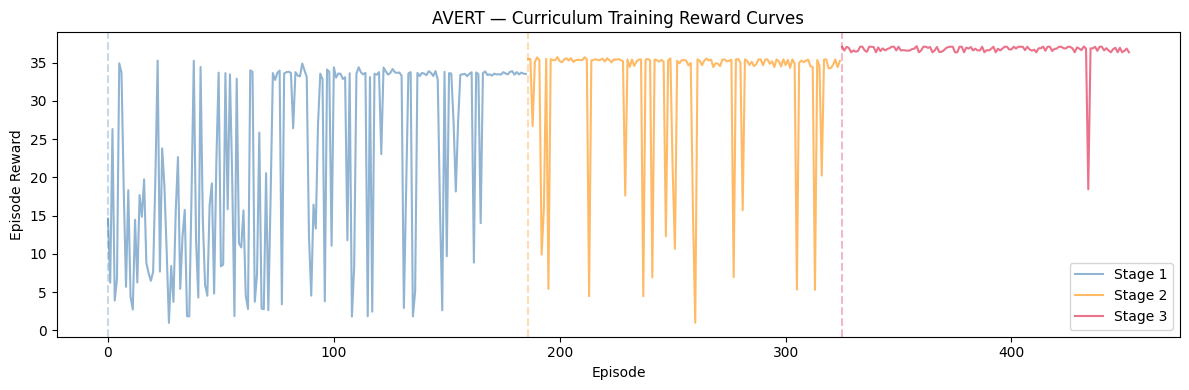

In [ ]:
stage_rewards = {
    "Stage 1": rewards_stage1,
    "Stage 2": rewards_stage2,
    "Stage 3": rewards_stage3,
}
plot_rewards(stage_rewards)

In [ ]:
def plot_comparison(curriculum_rewards, scratch_rewards):
    plt.figure(figsize=(10, 4))
    plt.plot(curriculum_rewards, label="Curriculum", color="steelblue", alpha=0.7)
    plt.plot(scratch_rewards, label="Scratch", color="crimson", alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title("AVERT — Curriculum vs Scratch on Stage 3")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}avert_comparison.png", dpi=150)
    plt.show()
    print(f"Saved to {SAVE_DIR}avert_comparison.png")

In [ ]:
def plot_transfer(roundabout_rewards, merge_rewards):
    plt.figure(figsize=(10, 4))
    plt.plot(roundabout_rewards, label="Roundabout Transfer", color="purple", alpha=0.7)
    plt.plot(merge_rewards, label="Merge Transfer", color="green", alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward")
    plt.title("AVERT — Transfer Learning: Roundabout vs Merge")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}avert_transfer_comparison.png", dpi=150)
    plt.show()
    print(f"Saved to {SAVE_DIR}avert_transfer_comparison.png")


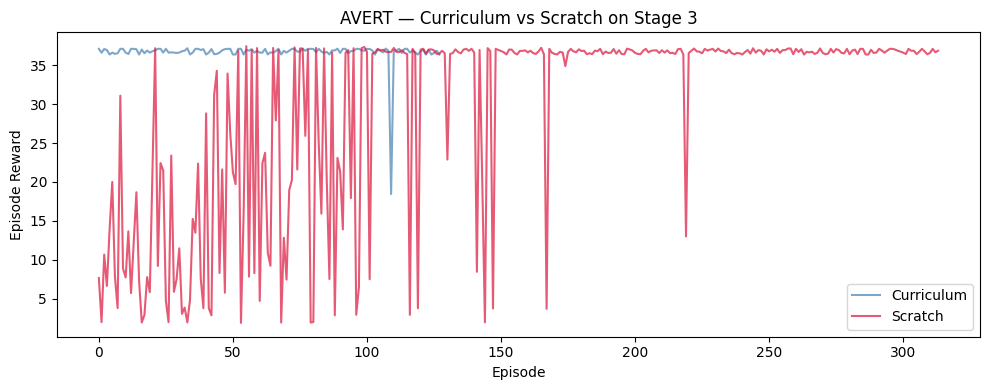

Saved to /content/drive/MyDrive/AVERT/avert_comparison.png


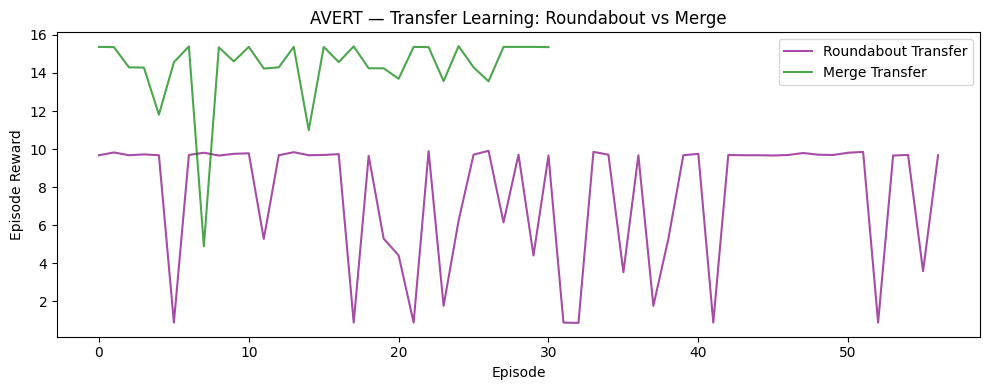

Saved to /content/drive/MyDrive/AVERT/avert_transfer_comparison.png


In [ ]:
plot_comparison(rewards_stage3_curriculum, rewards_stage3_scratch)
plot_transfer(rewards_roundabout_transfer, rewards_merge_transfer)

In [ ]:
print('Loading saved reward data for scratch roundabout and merge...')
rewards_roundabout_scratch = np.load(os.path.join(SAVE_DIR, "avert_roundabout_scratch_rewards.npy"))
rewards_merge_scratch = np.load(os.path.join(SAVE_DIR, "avert_merge_scratch_rewards.npy"))
print('Scratch reward data loaded successfully.')

Loading saved reward data for scratch roundabout and merge...
Scratch reward data loaded successfully.


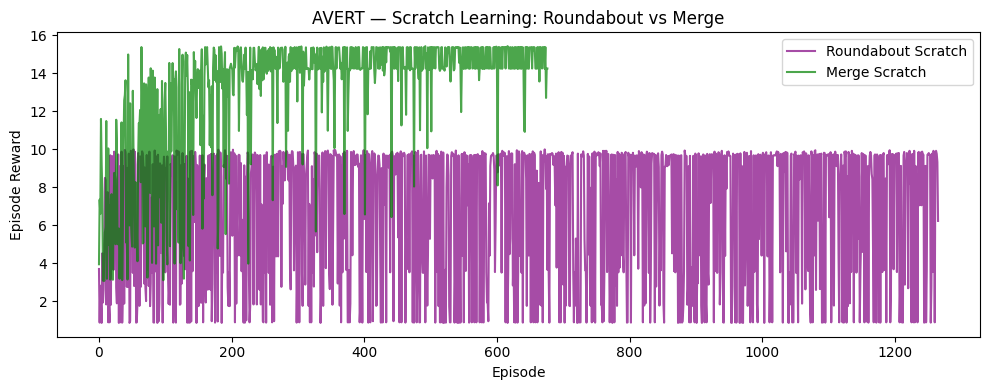

Saved to /content/drive/MyDrive/AVERT/avert_scratch_comparison.png


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(rewards_roundabout_scratch, label="Roundabout Scratch", color="purple", alpha=0.7)
plt.plot(rewards_merge_scratch, label="Merge Scratch", color="green", alpha=0.7)
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("AVERT — Scratch Learning: Roundabout vs Merge")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}avert_scratch_comparison.png", dpi=150)
plt.show()
print(f"Saved to {SAVE_DIR}avert_scratch_comparison.png")

In [ ]:
avg_reward_roundabout_scratch = np.mean(rewards_roundabout_scratch)
avg_reward_merge_scratch = np.mean(rewards_merge_scratch)

print(f"Average reward for Roundabout Scratch: {avg_reward_roundabout_scratch:.2f}")
print(f"Average reward for Merge Scratch: {avg_reward_merge_scratch:.2f}")

Average reward for Roundabout Scratch: 6.66
Average reward for Merge Scratch: 13.12


In [ ]:
print(f"Average reward for Stage 1 (Curriculum): {np.mean(rewards_stage1):.2f}")
print(f"Average reward for Stage 2 (Curriculum): {np.mean(rewards_stage2):.2f}")
print(f"Average reward for Stage 3 (Curriculum): {np.mean(rewards_stage3):.2f}")
print(f"Average reward for Stage 3 (Scratch): {np.mean(rewards_stage3_scratch):.2f}")
print(f"Average reward for Roundabout (Transfer): {np.mean(rewards_roundabout_transfer):.2f}")
print(f"Average reward for Merge (Transfer): {np.mean(rewards_merge_transfer):.2f}")

Average reward for Stage 1 (Curriculum): 22.95
Average reward for Stage 2 (Curriculum): 32.12
Average reward for Stage 3 (Curriculum): 36.66
Average reward for Stage 3 (Scratch): 29.73
Average reward for Roundabout (Transfer): 7.60
Average reward for Merge (Transfer): 14.28
